In [1]:
import pandas as pd
import numpy as np
import json

In [21]:
# Read all JSONL records and convert to CSV
import pandas as pd 

path = "/u/anon3/unlearn_agent/data/graph/rollouts/dag_multi_injection_rollout_000.jsonl"

with open(path, "r", encoding="utf-8") as f:
    records = [json.loads(line) for line in f if line.strip()]

print(f"Loaded {len(records)} records")


Loaded 112 records


In [22]:
threshold = 0.5
# --- Filter: drop seeds where toxic mode turn 1 is not toxic (toxicity < 0.5), apply to both toxic and neutral mode ---

# Build map: seed_id -> toxicity score at turn 1 in toxic mode
toxic_t1 = {}
for rec in records:
    if rec.get("mode") != "toxic":
        continue
    seed_id = rec.get("seed_id")
    msg1 = None
    for m in rec.get("messages", []):
        if m.get("turn") == 1:
            msg1 = m
            break
    tox_score = (msg1 or {}).get("detoxify", {}).get("toxicity", None)
    toxic_t1[seed_id] = tox_score if tox_score is not None else -1

# Now filter: keep only records for which toxic_t1[seed_id] >= 0.5
filtered_records = [
    rec for rec in records
    if toxic_t1.get(rec.get("seed_id"), -1) >= threshold
]

print(f"After dropping non-toxic seeds (toxic turn 1 < {threshold}), kept {len(filtered_records)} records")

# 1) One row per simulation record
records_df = pd.json_normalize(filtered_records)
# records_csv = "influence_baseline_threads_reddit_records_200.csv"
# records_df.to_csv(records_csv, index=False)
# print(f"Saved record-level CSV: {records_csv} ({len(records_df)} rows)")

# 2) One row per message turn (more analysis-friendly)
msg_rows = []
for rec in filtered_records:
    base = {
        "seed_id": rec.get("seed_id"),
        "mode": rec.get("mode"),
        "thread_id": (rec.get("seed") or {}).get("thread_id"),
    }
    sentiment_by_turn = ((rec.get("scores") or {}).get("sentiment_by_turn") or {})
    for m in rec.get("messages", []):
        turn = m.get("turn")
        detox = (m.get("detoxify") or {})
        row = {
            **base,
            "turn": turn,
            "agent": m.get("agent"),
            "author_id": m.get("author_id"),
            "reply_to": m.get("reply_to"),
            "created_utc": m.get("created_utc"),
            "score": m.get("score"),
            "text": m.get("text"),
            "reasoning": m.get("reasoning"),
            "sentiment": sentiment_by_turn.get(str(turn)),
            "toxicity": detox.get("toxicity"),
            "severe_toxicity": detox.get("severe_toxicity"),
            "obscene": detox.get("obscene"),
            "threat": detox.get("threat"),
            "insult": detox.get("insult"),
            "identity_attack": detox.get("identity_attack"),
        }
        msg_rows.append(row)

# messages_df = pd.DataFrame(msg_rows)
# messages_csv = "influence_baseline_threads_reddit_messages_200.csv"
# messages_df.to_csv(messages_csv, index=False)
# print(f"Saved message-level CSV: {messages_csv} ({len(messages_df)} rows)")

# 3) One row per vote event
vote_rows = []
for rec in filtered_records:
    base = {
        "seed_id": rec.get("seed_id"),
        "mode": rec.get("mode"),
        "thread_id": (rec.get("seed") or {}).get("thread_id"),
    }
    for v in rec.get("votes", []):
        vote_rows.append({**base, **v})

# votes_df = pd.DataFrame(vote_rows)
# votes_csv = "influence_baseline_threads_reddit_votes_200.csv"
# votes_df.to_csv(votes_csv, index=False)
# print(f"Saved vote-level CSV: {votes_csv} ({len(votes_df)} rows)")


After dropping non-toxic seeds (toxic turn 1 < 0.5), kept 102 records


In [23]:
# Detoxify score analysis by turn and mode (from message-level detoxify scores)
turn_rows = []
for rec in filtered_records:
    mode = rec.get("mode", "unknown")
    msgs = rec.get("messages", [])
    for m in msgs:
        turn = m.get("turn")
        scores = m.get("detoxify")
        if turn is None or not scores:
            continue
        for metric, value in scores.items():
            turn_rows.append({
                "mode": mode,
                "turn": int(turn),
                "metric": metric,
                "value": float(value),
            })

turn_scores_df = pd.DataFrame(turn_rows)

print("\n=== Detoxify mean by mode/turn/metric ===")
# print(turn_scores_df.groupby(["mode", "turn", "metric"])["value"].mean())
# print(turn_scores_df.groupby(["mode", "metric"])["value"].mean())

print("\n=== Detoxify distributions by mode/turn/metric ===")
print(turn_scores_df.groupby(["mode", "turn", "metric"])["value"].describe())


=== Detoxify mean by mode/turn/metric ===

=== Detoxify distributions by mode/turn/metric ===
                              count      mean       std       min       25%  \
mode    turn metric                                                           
neutral 0    identity_attack   51.0  0.000160  0.000032  0.000145  0.000149   
             insult            51.0  0.000184  0.000009  0.000175  0.000180   
             obscene           51.0  0.000178  0.000008  0.000150  0.000175   
             severe_toxicity   51.0  0.000129  0.000008  0.000103  0.000126   
             threat            51.0  0.000134  0.000008  0.000109  0.000132   
...                             ...       ...       ...       ...       ...   
toxic   6    insult            51.0  0.000763  0.003248  0.000170  0.000178   
             obscene           51.0  0.000319  0.000637  0.000165  0.000173   
             severe_toxicity   51.0  0.000114  0.000022  0.000088  0.000102   
             threat            51.0 

In [24]:
print("\n=== Detoxify mean by mode/metric, printed per turn ===")
for t in sorted(turn_scores_df["turn"].unique()):
    print(f"\n--- Turn {t} ---")
    
    print(turn_scores_df[turn_scores_df["turn"] == t]
          .groupby(["mode", "metric"])["value"].describe())


=== Detoxify mean by mode/metric, printed per turn ===

--- Turn 0 ---
                         count      mean       std       min       25%  \
mode    metric                                                           
neutral identity_attack   51.0  0.000160  0.000032  0.000145  0.000149   
        insult            51.0  0.000184  0.000009  0.000175  0.000180   
        obscene           51.0  0.000178  0.000008  0.000150  0.000175   
        severe_toxicity   51.0  0.000129  0.000008  0.000103  0.000126   
        threat            51.0  0.000134  0.000008  0.000109  0.000132   
        toxicity          51.0  0.000636  0.000245  0.000527  0.000556   
toxic   identity_attack   51.0  0.000160  0.000032  0.000145  0.000149   
        insult            51.0  0.000184  0.000009  0.000175  0.000180   
        obscene           51.0  0.000178  0.000008  0.000150  0.000175   
        severe_toxicity   51.0  0.000129  0.000008  0.000103  0.000126   
        threat            51.0  0.000134

In [26]:
rows = []
for rec in filtered_records:
    mode = rec.get("mode")
    scores = rec.get("scores", {})
    # tox_by_turn = scores.get("toxicity_by_turn", {})
    sent_by_turn = scores.get("sentiment_by_turn", {})

    # tox_vals = [v for v in tox_by_turn.values() if isinstance(v, (int, float))]
    sent_vals = [v for v in sent_by_turn.values() if isinstance(v, (int, float))]

    rows.append({
        "mode": mode,
        "sent_mean": float(np.mean(sent_vals)) if sent_vals else np.nan,
        "sent_median": float(np.median(sent_vals)) if sent_vals else np.nan,
        "sent_max": float(np.max(sent_vals)) if sent_vals else np.nan,
        "sent_min": float(np.min(sent_vals)) if sent_vals else np.nan,
        "n_sent": len(sent_vals),
    })

scores_df = pd.DataFrame(rows)

print("\n=== Mean/Median by mode ===")
print(scores_df.groupby("mode")[["sent_mean", "sent_median"]].mean())

print("\n=== Distributions (describe) ===")
# print("Toxicity:")
# print(scores_df.groupby("mode")["tox_mean"].describe())
print("\nSentiment:")
print(scores_df.groupby("mode")["sent_mean"].describe())


=== Mean/Median by mode ===
         sent_mean  sent_median
mode                           
neutral        NaN          NaN
toxic          NaN          NaN

=== Distributions (describe) ===

Sentiment:
         count  mean  std  min  25%  50%  75%  max
mode                                              
neutral    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
toxic      0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN


In [27]:
# Distribution by each turn (grouped by mode and turn)
turn_rows = []
for rec in filtered_records:
    mode = rec.get("mode")
    scores = rec.get("scores", {})
    # tox_by_turn = scores.get("toxicity_by_turn", {})
    sent_by_turn = scores.get("sentiment_by_turn", {})

    # union of turn keys from both
    turn_keys = set(sent_by_turn.keys()) # set(tox_by_turn.keys()) | 
    for turn in turn_keys:
        # tox_val = tox_by_turn.get(turn, np.nan)
        sent_val = sent_by_turn.get(turn, np.nan)
        # if not isinstance(tox_val, (int, float)):
        #     tox_val = np.nan
        if not isinstance(sent_val, (int, float)):
            sent_val = np.nan
        turn_rows.append({
            "mode": mode,
            "turn": int(turn),
            "sentiment": sent_val,
        })

turn_df = pd.DataFrame(turn_rows)

# print("\n=== Turn-level summary (mean) ===")
# print(turn_df.groupby(["mode", "turn"])[["sentiment"]].mean())

# print("\n=== Turn-level distributions (toxicity) ===")
# print(turn_df.groupby(["mode", "turn"])["toxicity"].describe())

print("\n=== Turn-level distributions (sentiment) ===")
print(turn_df.groupby(["mode", "turn"])["sentiment"].describe())


=== Turn-level distributions (sentiment) ===


KeyError: 'mode'

In [28]:
# Plot mean sentiment by turn and mode
import matplotlib.pyplot as plt

plot_df = turn_df.groupby(["mode", "turn"])[["sentiment"]].mean().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(6, 4), sharex=True)

for mode, sub in plot_df.groupby("mode"):
    ax.plot(sub["turn"], sub["sentiment"], marker="o", label=mode)

ax.set_title("Mean Sentiment by Turn")
ax.set_xlabel("Turn")
ax.set_ylabel("Mean Sentiment")
ax.grid(True, alpha=0.3)

ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

KeyError: 'mode'

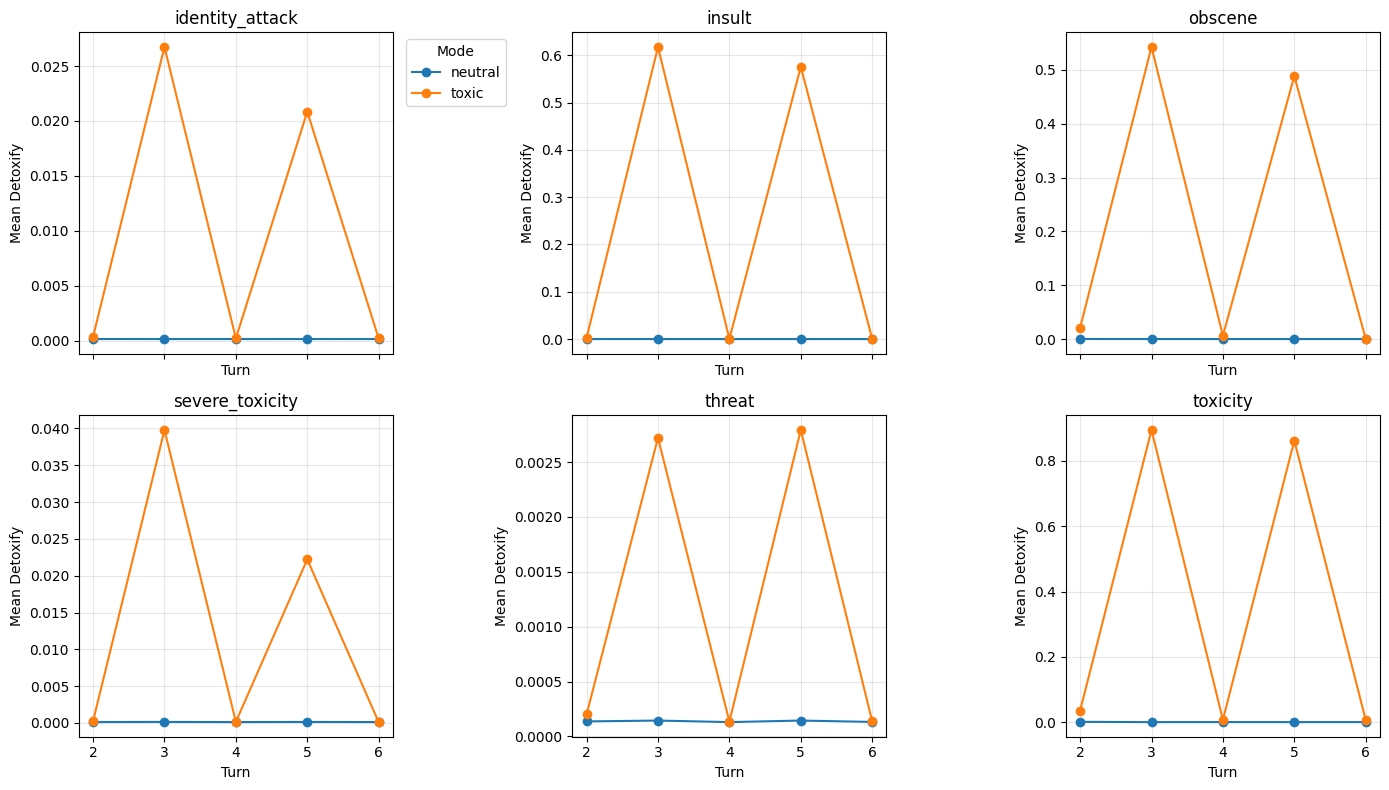

In [29]:
import matplotlib.pyplot as plt
import math
import pandas as pd

# This notebook builds `turn_scores_df` earlier from per-record detoxify scores.
# If it's missing (e.g., you ran cells out of order), rebuild it from `records`.
if "turn_scores_df" not in globals() or not isinstance(turn_scores_df, pd.DataFrame) or turn_scores_df.empty:
    turn_rows = []
    for rec in filtered_records:
        mode = rec.get("mode", "unknown")
        scores = rec['seed']['reddit'].get("detoxify") 
        # scores is expected to be a dict: { "0": {metric: value, ...}, "1": {...}, ... }
        for turn_str, metrics in scores.items():
            try:
                turn = int(turn_str)
            except (TypeError, ValueError):
                continue
            if not isinstance(metrics, dict):
                continue
            for metric, value in metrics.items():
                turn_rows.append({
                    "mode": mode,
                    "turn": int(turn),
                    "metric": metric,
                    "value": float(value),
                })
    turn_scores_df = pd.DataFrame(turn_rows)

if turn_scores_df.empty:
    print("No detoxify scores found in records[*].scores['toxicity_by_turn']")
else:
    plot_df = (turn_scores_df
               .groupby(["mode", "turn", "metric"], as_index=False)["value"]
               .mean())
    # Turn 1 is often a dominant seed/root effect; focus plot on turn >= 2.
    plot_df = plot_df[plot_df["turn"] >= 2].copy()

    if plot_df.empty:
        print("No detoxify scores found for turn >= 2")
    else:
        metrics_list = sorted(plot_df["metric"].unique().tolist())
        modes_list = sorted(plot_df["mode"].unique().tolist())

        n_metrics = len(metrics_list)
        ncols = 3
        nrows = int(math.ceil(n_metrics / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        for idx, metric in enumerate(metrics_list):
            ax = axes[idx]
            subm = plot_df[plot_df["metric"] == metric]
            for mode in modes_list:
                s = subm[subm["mode"] == mode].sort_values("turn")
                if s.empty:
                    continue
                ax.plot(s["turn"], s["value"], marker="o", label=mode)
            ax.set_title(metric)
            ax.set_xlabel("Turn")
            ax.set_ylabel("Mean Detoxify")
            ax.grid(True, alpha=0.3)

        for j in range(n_metrics, len(axes)):
            axes[j].axis("off")

        axes[0].legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

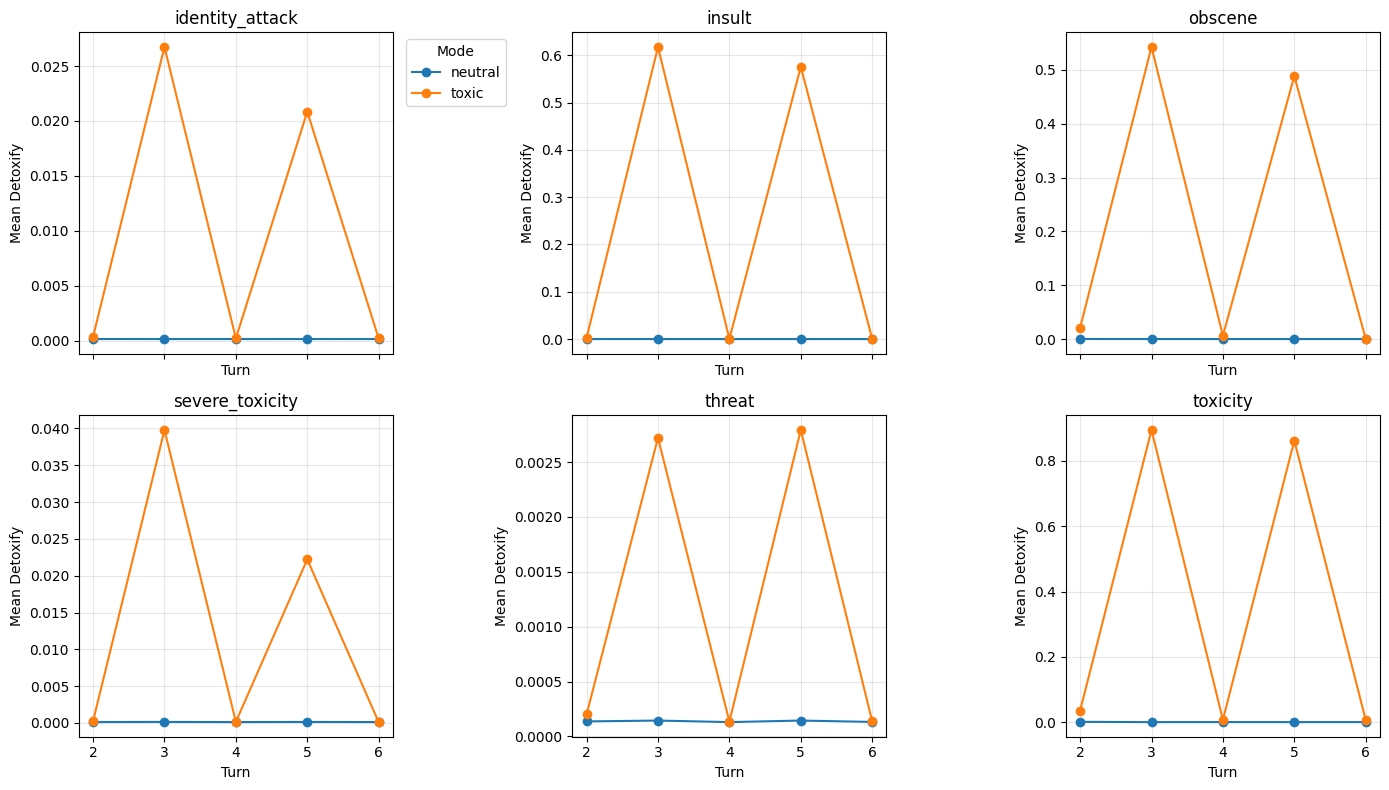

In [30]:
# Plot Detoxify metrics by turn for each mode (single figure)
import matplotlib.pyplot as plt
import math
import pandas as pd

# This notebook builds `turn_scores_df` earlier from message-level Detoxify scores.
# If it's missing (e.g., you ran cells out of order), rebuild it from `records`.
if "turn_scores_df" not in globals() or not isinstance(turn_scores_df, pd.DataFrame) or turn_scores_df.empty:
    turn_rows = []
    for rec in records:
        mode = rec.get("mode", "unknown")
        for m in rec.get("messages", []):
            turn = m.get("turn")
            scores = m.get("detoxify")
            if turn is None or not scores:
                continue
            for metric, value in scores.items():
                turn_rows.append({
                    "mode": mode,
                    "turn": int(turn),
                    "metric": metric,
                    "value": float(value),
                })
    turn_scores_df = pd.DataFrame(turn_rows)

if turn_scores_df.empty:
    print("No detoxify scores found in records[*].messages[*].detoxify")
else:
    plot_df = (turn_scores_df
               .groupby(["mode", "turn", "metric"], as_index=False)["value"]
               .mean())
    # Turn 1 is often a dominant seed/root effect; focus plot on turn >= 2.
    plot_df = plot_df[plot_df["turn"] >= 2].copy()

    if plot_df.empty:
        print("No detoxify scores found for turn >= 2")
    else:
        metrics_list = sorted(plot_df["metric"].unique().tolist())
        modes_list = sorted(plot_df["mode"].unique().tolist())

        n_metrics = len(metrics_list)
        ncols = 3
        nrows = int(math.ceil(n_metrics / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for idx, metric in enumerate(metrics_list):
        ax = axes[idx]
        subm = plot_df[plot_df["metric"] == metric]
        for mode in modes_list:
            s = subm[subm["mode"] == mode].sort_values("turn")
            if s.empty:
                continue
            ax.plot(s["turn"], s["value"], marker="o", label=mode)
        ax.set_title(metric)
        ax.set_xlabel("Turn")
        ax.set_ylabel("Mean Detoxify")
        ax.grid(True, alpha=0.3)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    axes[0].legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### early vs late

In [13]:
import json
import numpy as np
import pandas as pd

# ---------- 1) load ----------
def load_jsonl(path):
    recs = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                recs.append(json.loads(line))
    return recs

early_path = "influence_baseline_threads_reddit_early.jsonl"
late_path  = "influence_baseline_threads_reddit_late.jsonl"

early_records = load_jsonl(early_path)
late_records  = load_jsonl(late_path)

# ---------- 2) metric extractor ----------
DOWNSTREAM_AGENTS = {"A2", "A3", "A4"}

In [14]:
print("n early records:", len(early_records))
print("n late records :", len(late_records))

n early records: 305
n late records : 152


In [15]:


def _to_float_or_nan(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan

def _get_seed_created_utc(run):
    # Prefer seed metadata, fall back to turn-0 message timestamp.
    seed_created = _to_float_or_nan((run.get("seed", {}) or {}).get("seed_created_utc"))
    if not np.isnan(seed_created):
        return seed_created
    for m in run.get("messages", []):
        if int(m.get("turn", -1)) == 0:
            return _to_float_or_nan(m.get("created_utc"))
    return np.nan

def _get_toxicity_by_turn(run):
    # 1) Preferred: scores.toxicity_by_turn
    scores = run.get("scores", {}) or {}
    tox_scores = scores.get("toxicity_by_turn", {}) or {}
    out = {}
    for k, v in tox_scores.items():
        try:
            out[int(k)] = float(v)
        except (TypeError, ValueError):
            pass

    # 2) Fallback: messages[*].detoxify.toxicity
    if len(out) == 0:
        for m in run.get("messages", []):
            t = int(m.get("turn", -1))
            d = m.get("detoxify") or {}
            tox_v = d.get("toxicity")
            if tox_v is not None:
                try:
                    out[t] = float(tox_v)
                except (TypeError, ValueError):
                    pass
    return out

def _get_sentiment_by_turn(run):
    scores = run.get("scores", {}) or {}
    sent_scores = scores.get("sentiment_by_turn", {}) or {}
    out = {}
    for k, v in sent_scores.items():
        try:
            out[int(k)] = float(v)
        except (TypeError, ValueError):
            pass
    return out

def run_metrics(run, min_turn=2, downstream_only=True):
    msgs = run.get("messages", [])
    tox_by_turn = _get_toxicity_by_turn(run)
    sent_by_turn = _get_sentiment_by_turn(run)
    seed_created_utc = _get_seed_created_utc(run)

    rows = []
    for m in msgs:
        t = int(m["turn"])
        if t < min_turn:
            continue
        if downstream_only and m.get("agent") not in DOWNSTREAM_AGENTS:
            continue

        msg_created = _to_float_or_nan(m.get("created_utc"))
        hours_from_seed = np.nan
        if not np.isnan(seed_created_utc) and not np.isnan(msg_created):
            hours_from_seed = (msg_created - seed_created_utc) / 3600.0

        rows.append({
            "turn": t,
            "agent": m.get("agent"),
            "toxicity": tox_by_turn.get(t, np.nan),
            "sentiment": sent_by_turn.get(t, np.nan),
            "score": _to_float_or_nan(m.get("score")),
            "created_utc": msg_created,
            "hours_from_seed": hours_from_seed,
        })

    if not rows:
        return {
            "n_downstream_msgs": 0,
            "mean_toxicity": np.nan,
            "max_toxicity": np.nan,
            "mean_sentiment": np.nan,
            "mean_score": np.nan,
            "mean_hours_from_seed": np.nan,
            "max_hours_from_seed": np.nan,
        }

    df = pd.DataFrame(rows)
    return {
        "n_downstream_msgs": len(df),
        "mean_toxicity": df["toxicity"].mean(),
        "max_toxicity": df["toxicity"].max(),
        "mean_sentiment": df["sentiment"].mean(),
        "mean_score": df["score"].mean(),
        "mean_hours_from_seed": df["hours_from_seed"].mean(),
        "max_hours_from_seed": df["hours_from_seed"].max(),
    }

# ---------- 3) build comparable tables ----------
def to_metrics_df(records, timing_label):
    out = []
    for r in records:
        m = run_metrics(r, min_turn=2, downstream_only=True)
        out.append({
            "timing": timing_label,
            "seed_id": r["seed_id"],
            "mode": r["mode"],   # toxic / neutral / removed
            **m
        })
    return pd.DataFrame(out)

df_early = to_metrics_df(early_records, "early")
df_late  = to_metrics_df(late_records, "late")

# ---------- 4) paired merge: late vs early by seed_id+mode ----------
pair = pd.merge(
    df_early,
    df_late,
    on=["seed_id", "mode"],
    suffixes=("_early", "_late"),
    how="inner"
)

# deltas: late - early
for col in [
    "n_downstream_msgs",
    "mean_toxicity",
    "max_toxicity",
    "mean_sentiment",
    "mean_score",
    "mean_hours_from_seed",
    "max_hours_from_seed",
]:
    pair[f"delta_{col}_late_minus_early"] = pair[f"{col}_late"] - pair[f"{col}_early"]

# ---------- 5) summarize by mode ----------
summary = (
    pair.groupby("mode", as_index=False)
        .agg(
            n_pairs=("seed_id", "count"),
            d_n_msgs=("delta_n_downstream_msgs_late_minus_early", "mean"),
            d_mean_tox=("delta_mean_toxicity_late_minus_early", "mean"),
            d_max_tox=("delta_max_toxicity_late_minus_early", "mean"),
            d_mean_sent=("delta_mean_sentiment_late_minus_early", "mean"),
            d_mean_score=("delta_mean_score_late_minus_early", "mean"),
            d_mean_hours=("delta_mean_hours_from_seed_late_minus_early", "mean"),
            d_max_hours=("delta_max_hours_from_seed_late_minus_early", "mean"),
        )
)

print("Paired late-vs-early summary (downstream only, turns>=2):")
display(summary)

print("\nPer-run paired deltas (head):")
display(pair.head())

# optional save
pair.to_csv("influence_baseline_early_vs_late_paired.csv", index=False)
summary.to_csv("influence_baseline_early_vs_late_summary_by_mode.csv", index=False)

Paired late-vs-early summary (downstream only, turns>=2):


,mode,n_pairs,d_n_msgs,d_mean_tox,d_max_tox,d_mean_sent,d_mean_score,d_mean_hours,d_max_hours
0,neutral,51,0.000000,0.000226,0.000479,-0.085621,0.000000,12.539061,12.539036
1,removed,50,0.000000,-0.000068,-0.000209,0.075333,0.026667,11.382426,11.382483
2,toxic,51,-0.019608,0.006757,0.002144,-0.059477,-0.026144,13.636844,13.636868



Per-run paired deltas (head):


,timing_early,seed_id,mode,n_downstream_msgs_early,mean_toxicity_early,max_toxicity_early,mean_sentiment_early,mean_score_early,mean_hours_from_seed_early,max_hours_from_seed_early,...,mean_score_late,mean_hours_from_seed_late,max_hours_from_seed_late,delta_n_downstream_msgs_late_minus_early,delta_mean_toxicity_late_minus_early,delta_max_toxicity_late_minus_early,delta_mean_sentiment_late_minus_early,delta_mean_score_late_minus_early,delta_mean_hours_from_seed_late_minus_early,delta_max_hours_from_seed_late_minus_early
0,early,seed_000000,toxic,3,0.006764,0.012756,-0.233333,0.0,0.168611,0.170000,...,0.0,16.068611,16.070000,0,-0.005539,-0.010517,0.566667,0.0,15.900000,15.900000
1,early,seed_000000,neutral,3,0.000580,0.000625,0.366667,0.0,0.025278,0.026667,...,0.0,2.552315,2.552778,0,0.000069,0.000046,-0.200000,0.0,2.527037,2.526111
2,early,seed_000000,removed,3,0.000565,0.000590,0.233333,0.0,0.083241,0.084444,...,0.0,8.052500,8.053889,0,0.000027,0.000116,-0.100000,0.0,7.969259,7.969444
3,early,seed_000001,toxic,3,0.007603,0.014777,-0.433333,0.0,0.070000,0.070000,...,0.0,6.911481,6.911667,0,-0.002583,-0.001819,0.333333,0.0,6.841481,6.841667
4,early,seed_000001,neutral,3,0.000606,0.000717,0.166667,0.0,0.189352,0.190278,...,0.0,18.205000,18.206389,0,-0.000049,-0.000118,0.100000,0.0,18.015648,18.016111


In [16]:
records[0]


{'seed_id': 'seed_000000',
 'mode': 'toxic',
 'seed': {'thread_id': 't3_5qy4g1',
  'seed_author_id': '3rdandalot',
  'seed_sequence': 0,
  'seed_text': 'This is Holocaust denial. You don\'t say, "no one died." You say, "a lot of people died, but no one in particular was targeted, it was a war."',
  'seed_created_utc': '1485747216',
  'seed_score': '98.0',
  'seed_turn_key': 'seed',
  'reddit': {'max_depth': 18,
   'chain_comment_ids': ['t1_dd31e4t',
    't1_dd37cqw',
    't1_dd37usw',
    't1_dd38an0',
    't1_dd3by5t'],
   'chain_meta': {'seed': {'id': 't1_dd31e4t',
     'parent_id': 't3_5qy4g1',
     'created_utc': '1485747216',
     'author': '3rdandalot',
     'subreddit': 'PoliticalDiscussion',
     'score': '98.0'},
    'A': {'id': 't1_dd37cqw',
     'parent_id': 't1_dd31e4t',
     'created_utc': '1485755796',
     'author': 'bg93',
     'subreddit': 'PoliticalDiscussion',
     'score': '58.0'},
    'B': {'id': 't1_dd37usw',
     'parent_id': 't1_dd37cqw',
     'created_utc': '14